In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'
import torch
import pytorch_lightning as pl
import scanpy as sc
import numpy as np
import pandas as pd
import time
from torch.utils.data import DataLoader, TensorDataset
from sclmct.model import TrainWrapperCLIPStyle
from sclmct.dataset import H5ADDataset, LOG1PTransform, TotalSumNormalize
from sclmct.utils import predict_with_distance_weights, get_semantics_labels, get_latent_representations
# from sclmct.paths import DATA_DIR, MODELS_DIR, RESULTS_DIR, CONFIGS_DIR
SEED = 1

class ARGS:
    def __init__(self, l_lambda, use_proj, block_type, arc_m, arc_s, text_encoder_model):
        self.out_dir = "Ablation"
        self.classifier = "faiss"
        self.workers = 12
        self.seed = 1
        self.fold = 0
        self.device = 4
        self.max_epoch = 200
        self.cal_umap = False
        self.cal_silhouette = False
        self.parallel = False
        self.test = False
        self.loss_type = 'combine'
        self.l_lambda = l_lambda
        self.use_projection_head = use_proj
        self.block_type = block_type
        self.arc_m = arc_m
        self.arc_s = arc_s
        self.clip_loss_type = 'label'
        self.prompt_template = "cell_types_info"
        self.text_encoder_model = text_encoder_model
        self.save_root = "./results"

config = {
        "l_lambda": 0.5,
        "use_proj": False,
        "block_type": 'v2',
        "arc_m": 0.4,
        "arc_s": 30.0,
    }



text_encoder_model = 'michiyasunaga/BioLinkBERT-base'
l_lambda, use_proj, block_type, arc_m, arc_s = config['l_lambda'], config['use_proj'], config['block_type'], config['arc_m'], config['arc_s']

args = ARGS(l_lambda, use_proj, block_type, arc_m, arc_s, text_encoder_model)

/home/dungp/miniconda3/envs/sclmct/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading new data

In [2]:

train_file_path = '/data/share/dungp/single-cell/ct-classification/code4publication/code-for-reproducibility/scLMCT/data/cellxgene/brain/train.h5ad'
test_file_path = '/data/share/dungp/single-cell/ct-classification/code4publication/code-for-reproducibility/scLMCT/data/cellxgene/brain/test.h5ad'
# file_size_gb = os.path.getsize(train_file_path) / (1024 ** 3)
# print(f"Train file size: {file_size_gb:.2f} GB")

train_adata = sc.read(train_file_path)
test_adata = sc.read(test_file_path)
cell_type_col = 'cell_type'

## data normalization
if train_adata.X.max() > 50:
    sc.pp.normalize_total(train_adata, target_sum=1e4)
    sc.pp.log1p(train_adata)
if test_adata.X.max() > 50:
    sc.pp.normalize_total(test_adata, target_sum=1e4)
    sc.pp.log1p(test_adata)

train_adata.obs[cell_type_col] = train_adata.obs[cell_type_col].str.lower().replace('_', ' ')
test_adata.obs[cell_type_col] = test_adata.obs[cell_type_col].str.lower().replace('_', ' ')
train_label_dict = {ct:i for i, ct in enumerate(train_adata.obs[cell_type_col].unique())}


train_ds = TensorDataset(torch.tensor(train_adata.X.A if isinstance(train_adata.X, np.ndarray) else train_adata.X.toarray(), dtype=torch.float32),
                        torch.tensor(train_adata.obs[cell_type_col].map(train_label_dict).values, dtype=torch.long))


semantics_labels = get_semantics_labels(train_label_dict, None)


In [3]:
batch_size = 256
g = torch.Generator().manual_seed(SEED)


train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True,
                            worker_init_fn=lambda i: np.random.seed(SEED+i), generator=g)

## path to save the Text encoder cache (output of the second-to-last layer)
cache_path = os.path.join("./cache/cached_prompt_embeddings.pt")
## remove if cache exists
if os.path.exists(cache_path):
    os.remove(cache_path)
if not os.path.exists(os.path.dirname(cache_path)):
    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
D_input = next(iter(train_loader))[0].shape[-1]


In [4]:
model = TrainWrapperCLIPStyle(
    input_dim=D_input,
    hidden_dim=512,
    output_dim=None,
    label_prompts=semantics_labels,
    n_cell_layers=2,
    block_type=args.block_type,
    text_encoder_model=args.text_encoder_model,
    use_projection_head=args.use_projection_head,
    n_prompts=5,
    pool_type="mean",
    n_text_layers_to_finetune=1,
    device="cuda",
    cache_path=cache_path,
    lr=1e-4,
    weight_decay=1e-4,
    arc_s=args.arc_s,
    arc_m=args.arc_m,
    f_gamma=1.3,
    l_lambda=args.l_lambda,
    clip_loss_type=args.clip_loss_type,
)

callbacks = [
    pl.callbacks.EarlyStopping(monitor="train_loss", patience=5, min_delta=0.001),
    pl.callbacks.ModelCheckpoint(dirpath=os.path.join("./results", "checkpoints"),
                                monitor="train_loss", save_top_k=1, mode="min")
]

trainer = pl.Trainer(
    max_epochs=args.max_epoch,
    accelerator="gpu",
    devices=[0],
    callbacks=callbacks,
    gradient_clip_val=1.0,
    deterministic=True,
)

start = time.time()
trainer.fit(model, train_loader)
model = TrainWrapperCLIPStyle.load_from_checkpoint(trainer.checkpoint_callback.best_model_path)
print(f"Training finished in {time.time() - start:.2f} seconds.")

[INFO] Loaded model with 12 transformer layers.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/dungp/miniconda3/envs/sclmct/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
You are using a CUDA device ('NVIDIA RTX A6000') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_floa

[INFO] No projection_dim provided, using hidden_size as projection_dim.


/home/dungp/miniconda3/envs/sclmct/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:701: Checkpoint directory /data/share/dungp/single-cell/ct-classification/code4publication/scLMCT/experiments/cell_type_annotation/scLMCT/results/checkpoints exists and is not empty.


[INFO] Generating prompt cache...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [2]

  | Name                 | Type                       | Params | Mode 
----------------------------------------------------------------------------
0 | text_encoder_wrapper | TextEncoderWrapper         | 108 M  | train
1 | encoder              | CellEncoder                | 14.4 M | train
2 | clip_loss            | CellTextContrastiveLoss    | 0      | train
3 | text_center_loss     | TextCentersContrastiveLoss | 1      | train
----------------------------------------------------------------------------
21.5 M    Trainable params
101 M     Non-trainable params
122 M     Total params
490.436   Total estimated model params size (MB)
29        Modules in train mode
228       Modules in eval mode
/home/dungp/miniconda3/envs/sclmct/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` arg

[INFO] Saved prompt cache to ./cache/cached_prompt_embeddings.pt
Epoch 10: 100%|██████████| 48/48 [00:05<00:00,  8.33it/s, v_num=8, train_loss=3.18e-5, loss_clip=2.52e-5, loss_text_text=3.85e-5] 
[INFO] Loaded model with 12 transformer layers.
[INFO] No projection_dim provided, using hidden_size as projection_dim.
Training finished in 57.48 seconds.


In [5]:

train_lat = get_latent_representations(
        train_adata.X.A if isinstance(train_adata.X, np.ndarray) else train_adata.X.toarray(),
        model = model,
        batch_size=256,
        device = "cuda"
    )

test_lat = get_latent_representations(
    test_adata.X.A if isinstance(test_adata.X, np.ndarray) else test_adata.X.toarray(),
    model = model,
    batch_size=256,
    device = "cuda"
)
train_labels = train_adata.obs[cell_type_col].values
test_labels = test_adata.obs[cell_type_col].values

In [6]:
train_adata.X.max()

np.float32(8.721177)

In [7]:
## KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

knn = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='cosine')
knn.fit(train_lat, train_labels)
test_pred = knn.predict(test_lat)

print(classification_report(test_labels, test_pred, digits=2))

                                        precision    recall  f1-score   support

                             astrocyte       0.98      0.91      0.94       329
                                b cell       1.00      0.69      0.82        13
                        dendritic cell       0.30      0.38      0.33         8
                      endothelial cell       0.94      0.89      0.91       194
                       epithelial cell       1.00      1.00      1.00      1031
                            fibroblast       0.78      1.00      0.88         7
                             leukocyte       0.92      0.43      0.59        28
                            macrophage       0.90      0.92      0.91       121
                       microglial cell       0.97      0.91      0.94        65
                                neuron       0.98      1.00      0.99      2481
                       oligodendrocyte       0.97      0.99      0.98      2237
        oligodendrocyte precursor cell 

### Visualization

/home/dungp/miniconda3/envs/sclmct/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


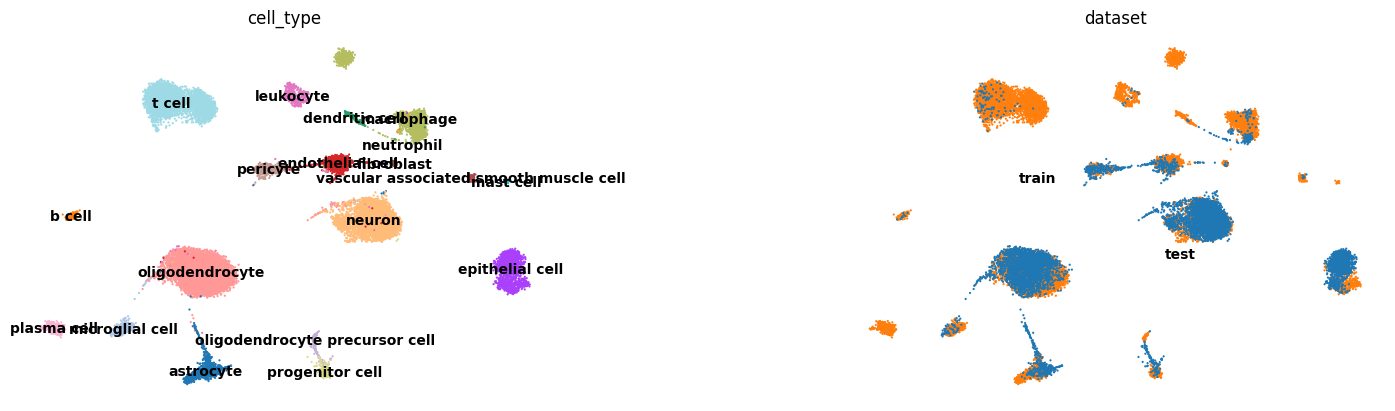

In [8]:
## plot both train and test
plot_adata = sc.AnnData(np.concatenate([train_lat, test_lat], axis=0))
obs_df = pd.DataFrame({
    'cell_type': np.concatenate([train_labels, test_labels], axis=0),
    'dataset': ['train'] * len(train_labels) + ['test'] * len(test_labels)
})
plot_adata.obs = obs_df
sc.pp.neighbors(plot_adata, use_rep='X')
sc.tl.umap(plot_adata)
sc.pl.umap(plot_adata, color=['cell_type', 'dataset'], wspace=0.4, size=10, frameon=False, legend_loc='on data', show=True)
